In [2]:
import os
import pandas as pd

def search_keywords_in_filenames(directory, keywords):
    files = os.listdir(directory)
    keyword_pairs = [(keywords[i], keywords[j]) for i in range(len(keywords)) for j in range(len(keywords))]
    dataframe = pd.DataFrame()

    for file in files:
        if file.endswith('.csv'):
            for keyword1, keyword2 in keyword_pairs:
                if keyword1 == keyword2:
                    if file.count(keyword1) >= 2:
                        file_path = os.path.join(directory, file)
                        df = pd.read_csv(file_path, usecols=[0],header=None)
                        df=pd.DataFrame(df[0].values.reshape(-1, 2).mean(axis=1))
                        column_name = f"{keyword1}:{keyword2}"
                        df.columns = [column_name]
                        if dataframe.empty:
                            dataframe = df
                        else:
                            dataframe = pd.concat([dataframe, df], axis=1)
                        
                elif keyword1 in file and keyword2 in file:
                        keyword1_index = file.index(keyword1)
                        keyword2_index = file.index(keyword2)
                        if keyword1_index < keyword2_index:
                            file_path = os.path.join(directory, file)
                            df = pd.read_csv(file_path, usecols=[0],header=None)
                            df=pd.DataFrame(df[0].values.reshape(-1, 2).mean(axis=1))
                            column_name = f"{keyword1}:{keyword2}"
                            df.columns = [column_name]
                            if dataframe.empty:
                                dataframe = df
                            else:
                                dataframe = pd.concat([dataframe, df], axis=1)                            

    return dataframe


In [ ]:
# Example usage
directory = '../prediction/enhancer10kb'
#directory = 'D:\THP1_machinelearning\prediction\enhancer10kb2'
keywords = ['H1_resting','H1_IFNB','WTC11_resting','WTC11_IFNB','HEK293T_ATAC', 'Cortex_AgeB', 'Cortex_AgeC','Striatum_AgeC','Striatum_AgeB', 'HEK293_ATAC','THP1_monocyte','THP1_Naive','THP1_IFNG','THP1_IFNB','THP1_LPSIFNG']
result_df = search_keywords_in_filenames(directory, keywords).sort_index(axis=1)

result_df

files = os.listdir('../expand_peaks_500bp_hg38andmm10' )
exclude_files = {
    'THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.narrowPeak.validation.withNeg.bed',
    'THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.narrowPeak.validation.withNeg.bed',
    'THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.narrowPeak.validation.withNeg.bed',
    'THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.narrowPeak.validation.withNeg.bed'
}
dataframe = pd.DataFrame()
keyword_bed = []
for file in files:
    if file.endswith('.bed'):
        for key in keywords:
            if key in file and "validation.withNeg" in file and file not in exclude_files:
                keyword_bed.append(key)
                file_path = os.path.join('../expand_peaks_500bp_hg38andmm10' , file)

                df = pd.read_csv(file_path, usecols=[6],sep='\t',header=None)
                df.columns = [key]
                dataframe = pd.concat([dataframe, df], axis=1)
dataframe

,HEK293_ATAC,HEK293T_ATAC,THP1_IFNB,THP1_IFNG,THP1_LPSIFNG,THP1_monocyte,THP1_Naive,Cortex_AgeB,Cortex_AgeC,Striatum_AgeB,Striatum_AgeC,H1_IFNB,WTC11_resting,WTC11_IFNB,H1_resting
0,15.66117,22.03607,25.67301,17.95337,28.38107,19.86359,29.89225,25.21521,30.15757,24.19288,21.90597,25.43425,16.11002,15.40199,24.19492
1,18.16805,21.38128,16.81564,19.09294,24.47928,24.48176,26.91918,10.96971,30.82817,30.89295,28.19796,22.71161,29.27079,23.78719,22.07085
2,11.07569,29.27972,28.99120,27.32794,17.22519,19.11042,16.75376,6.71093,25.50907,25.89378,30.91694,18.26496,23.35918,23.34486,17.78422
3,18.61318,32.34783,26.03690,29.95352,26.07158,16.57298,28.64725,13.11134,32.51313,25.30883,24.80088,25.78449,29.58780,30.30447,25.25264
4,15.10836,17.79196,16.72074,26.85795,22.02252,22.42136,17.49256,28.00000,23.80305,15.27117,30.08012,19.04907,23.28845,28.35258,20.38763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19491,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,NaN,NaN,NaN,NaN,NaN,NaN
19492,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,NaN,NaN,NaN,NaN,NaN,NaN
19493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,NaN,NaN,NaN,NaN,NaN,NaN
19494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Example usage
directory = '../prediction/enhancer10kb_test' 
#directory = 'D:\THP1_machinelearning\prediction\enhancer10kb2'
keywords = ['H1_resting','H1_IFNB','WTC11_resting','WTC11_IFNB','HEK293T_ATAC', 'Cortex_AgeB', 'Cortex_AgeC','Striatum_AgeC','Striatum_AgeB', 'HEK293_ATAC','THP1_monocyte','THP1_Naive','THP1_IFNG','THP1_IFNB','THP1_LPSIFNG']
result_df = search_keywords_in_filenames(directory, keywords).sort_index(axis=1)

result_df


files = os.listdir('../expand_peaks_500bp_hg38andmm10' )
exclude_files = {
    'THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.narrowPeak.test.withNeg.bed',
    'THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.narrowPeak.test.withNeg.bed',
    'THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.narrowPeak.test.withNeg.bed',
    'THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.narrowPeak.test.withNeg.bed'
}
dataframe = pd.DataFrame()
keyword_bed = []
for file in files:
    if file.endswith('.bed'):
        for key in keywords:
            if key in file and "test.withNeg" in file and file not in exclude_files:
                keyword_bed.append(key)
                file_path = os.path.join('../expand_peaks_500bp_hg38andmm10' , file)

                df = pd.read_csv(file_path, usecols=[6],sep='\t',header=None)
                df.columns = [key]
                dataframe = pd.concat([dataframe, df], axis=1)
dataframe


,Cortex_AgeB:Cortex_AgeB,Cortex_AgeB:Cortex_AgeC,Cortex_AgeB:H1_IFNB,Cortex_AgeB:H1_resting,Cortex_AgeB:HEK293T_ATAC,Cortex_AgeB:HEK293_ATAC,Cortex_AgeB:Striatum_AgeB,Cortex_AgeB:Striatum_AgeC,Cortex_AgeB:THP1_IFNB,Cortex_AgeB:THP1_IFNG,...,WTC11_resting:HEK293_ATAC,WTC11_resting:Striatum_AgeB,WTC11_resting:Striatum_AgeC,WTC11_resting:THP1_IFNB,WTC11_resting:THP1_IFNG,WTC11_resting:THP1_LPSIFNG,WTC11_resting:THP1_Naive,WTC11_resting:THP1_monocyte,WTC11_resting:WTC11_IFNB,WTC11_resting:WTC11_resting
0,13.347634,10.664605,5.349757,5.349757,5.049206,2.654243,0.519881,2.719792,2.044871,3.128954,...,2.429039,0.550706,0.381798,2.123606,2.304810,2.113619,2.022786,9.292958,3.546985,3.804979
1,9.146765,0.490485,3.681540,3.572085,6.823472,7.983638,10.664605,0.490485,1.331385,5.027846,...,2.696549,7.953925,0.471147,2.924266,1.459543,1.511118,1.380999,1.698829,1.475646,2.333102
2,2.821551,5.500678,10.841178,11.048903,1.897370,5.920606,6.448155,7.411110,4.602947,4.602947,...,0.462249,6.797955,3.100938,1.368410,1.368410,6.335603,2.971423,3.546985,0.894472,0.861499
3,1.219250,8.085530,3.319326,8.248030,3.255465,1.712105,8.448258,4.998150,4.866980,6.036137,...,0.089985,6.486341,3.923970,1.371039,2.356694,1.499535,3.804979,1.697188,2.323917,1.412075
4,5.075590,14.751055,4.436471,5.493058,7.235458,2.495163,3.367894,6.618092,5.689312,9.736692,...,0.577203,0.326004,0.969656,6.311323,7.295527,5.090636,1.411577,8.396251,3.427924,9.693256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32169,NaN,5.894533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32170,NaN,1.553528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32171,NaN,6.102093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32172,NaN,2.472633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


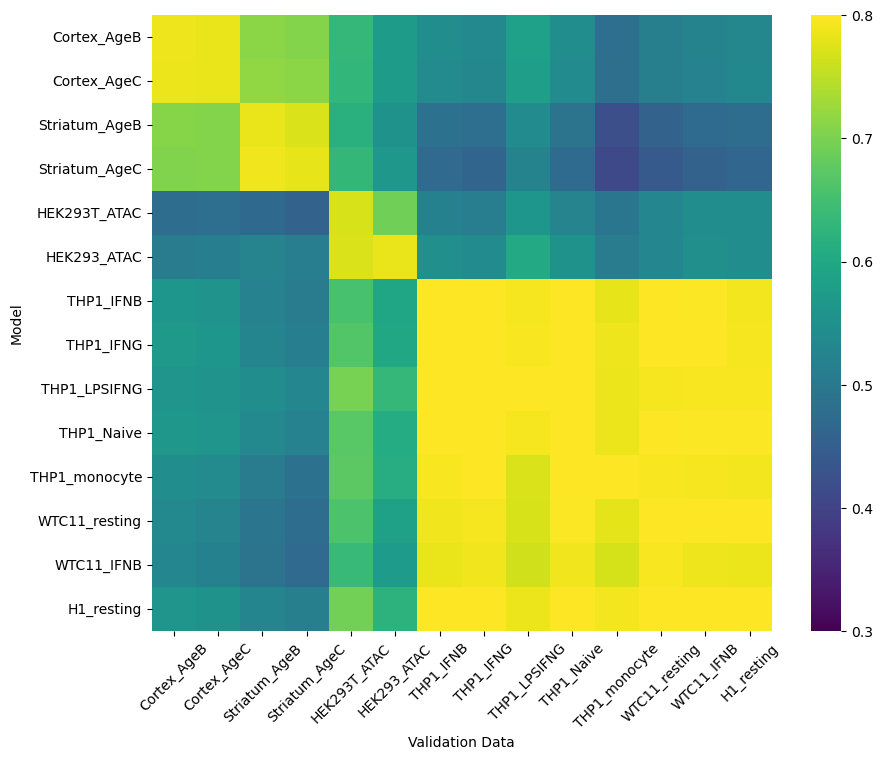

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Calculating correlation
correlation = []
for c in result_df.columns:
    model = c.split(':')[0]
    validation = c.split(':')[1]
    for d in dataframe.columns:
        if validation == d:
            statistic, p = stats.spearmanr(result_df[c].dropna().reset_index(drop=True), dataframe[d].dropna().reset_index(drop=True))
            correlation.append([model, validation, statistic, p])

df = pd.DataFrame(correlation, columns=['Model', 'Validation Data', 'Value', 'Extra'])
df_pivot = df.pivot(index='Model', columns='Validation Data', values='Value')

# Columns for the heatmap
columns = ['Cortex_AgeB', 'Cortex_AgeC', 
           'Striatum_AgeB', 'Striatum_AgeC', 'HEK293T_ATAC', 'HEK293_ATAC', 'THP1_IFNB', 'THP1_IFNG',
           'THP1_LPSIFNG', 'THP1_Naive', 'THP1_monocyte','WTC11_resting','WTC11_IFNB','H1_resting']

# Creating the heatmap
plt.figure(figsize=(10, 8))  # Adjusting figure size if needed
heatmap = sns.heatmap(df_pivot.loc[columns, columns], annot=False, cmap='viridis', cbar=True, vmin=0.3, vmax=0.8)
#plt.title("CNN Trained on Specific Cell Types vs Both Positive and Negative Sequences in Validation Data")
plt.xticks(rotation=45)
# Saving the figure with high DPI
plt.savefig('Models_vs_test.pdf', dpi=300, bbox_inches='tight')  # You can adjust the dpi value as needed
plt.show()


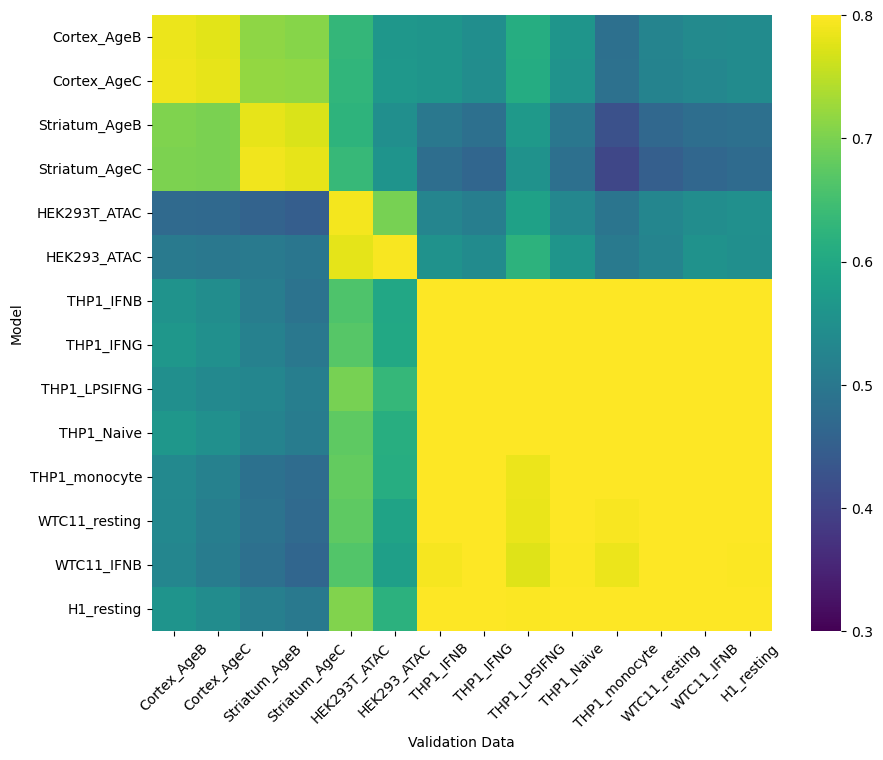

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Calculating correlation
correlation = []
for c in result_df.columns:
    model = c.split(':')[0]
    validation = c.split(':')[1]
    for d in dataframe.columns:
        if validation == d:
            statistic, p = stats.spearmanr(result_df[c].dropna().reset_index(drop=True), dataframe[d].dropna().reset_index(drop=True))
            correlation.append([model, validation, statistic, p])

df = pd.DataFrame(correlation, columns=['Model', 'Validation Data', 'Value', 'Extra'])
df_pivot = df.pivot(index='Model', columns='Validation Data', values='Value')

# Columns for the heatmap
columns = ['Cortex_AgeB', 'Cortex_AgeC', 
           'Striatum_AgeB', 'Striatum_AgeC', 'HEK293T_ATAC', 'HEK293_ATAC', 'THP1_IFNB', 'THP1_IFNG',
           'THP1_LPSIFNG', 'THP1_Naive', 'THP1_monocyte','WTC11_resting','WTC11_IFNB','H1_resting']

# Creating the heatmap
plt.figure(figsize=(10, 8))  # Adjusting figure size if needed
heatmap = sns.heatmap(df_pivot.loc[columns, columns], annot=False, cmap='viridis', cbar=True, vmin=0.3, vmax=0.8)
#plt.title("CNN Trained on Specific Cell Types vs Both Positive and Negative Sequences in Validation Data")
plt.xticks(rotation=45)
# Saving the figure with high DPI
plt.savefig('Models_vs_Validations2.pdf', dpi=300, bbox_inches='tight')  # You can adjust the dpi value as needed
plt.show()


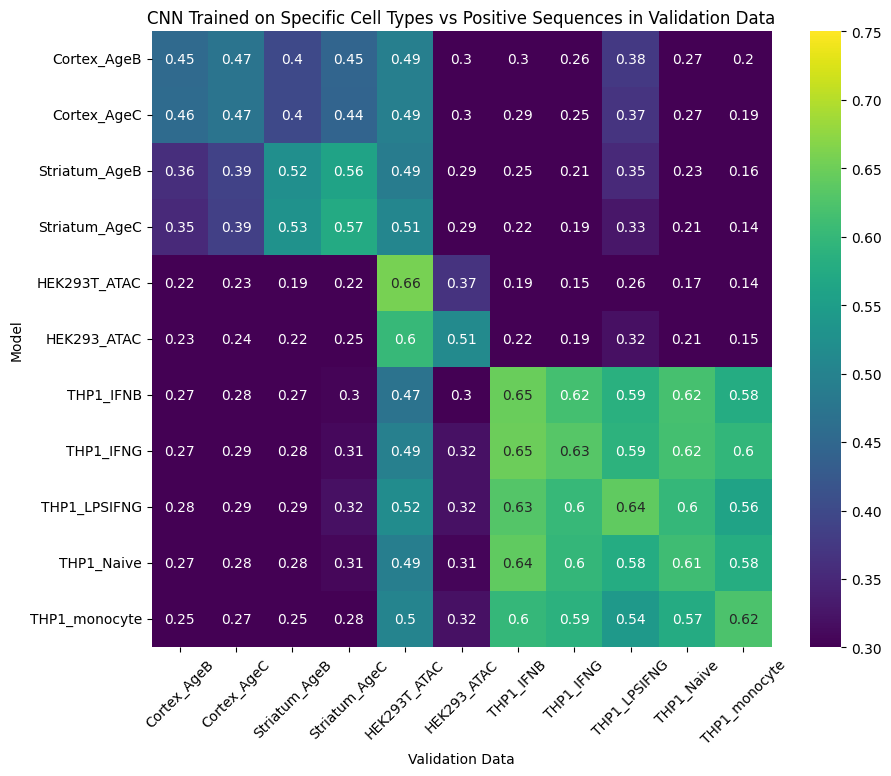

Number of positive validation peak: HEK293_ATAC | 5523
Number of positive validation peak: HEK293T_ATAC | 5346
Number of positive validation peak: THP1_IFNB | 9734
Number of positive validation peak: THP1_IFNG | 9117
Number of positive validation peak: THP1_LPSIFNG | 7140
Number of positive validation peak: THP1_monocyte | 9795
Number of positive validation peak: THP1_Naive | 9385
Number of positive validation peak: Cortex_AgeB | 9017
Number of positive validation peak: Cortex_AgeC | 10352
Number of positive validation peak: Striatum_AgeB | 7789
Number of positive validation peak: Striatum_AgeC | 9486


In [81]:
from scipy import stats
correlation = []
for c in result_df.columns:
    model = c.split(':')[0]
    validation = c.split(':')[1]
    for d in dataframe.columns:
        if validation== d:
            
            data = dataframe[d].dropna().reset_index(drop=True)
            data_pos = data[data!=0]
            
            predict = result_df[c].dropna().reset_index(drop=True)
            predict_pos = predict[data!=0]
            statistic, p = stats.spearmanr(data_pos,predict_pos)
            correlation.append([model, validation, statistic, p])

df = pd.DataFrame(correlation, columns=['Model', 'Validation Data', 'Value', 'Extra'])
df_pivot = df.pivot(index='Model', columns='Validation Data', values='Value')
import seaborn as sns
columns = ['Cortex_AgeB', 'Cortex_AgeC', 
       'Striatum_AgeB', 'Striatum_AgeC','HEK293T_ATAC', 'HEK293_ATAC', 'THP1_IFNB', 'THP1_IFNG',
       'THP1_LPSIFNG', 'THP1_Naive', 'THP1_monocyte']
# Creating the heatmap
plt.figure(figsize=(10, 8))  # Adjusting figure size if needed
heatmap = sns.heatmap(df_pivot.loc[columns, columns], annot=True, cmap='viridis', cbar=True, vmin=0.3, vmax=0.75)
plt.title("CNN Trained on Specific Cell Types vs Positive Sequences in Validation Data")
plt.xticks(rotation=45)
# Saving the figure with high DPI
plt.savefig('Models_vs_PositiveValidations.pdf', dpi=300, bbox_inches='tight')  # You can adjust the dpi value as needed
plt.show()

for d in dataframe.columns:
    data = dataframe[d].dropna().reset_index(drop=True)
    data_pos = data[data!=0]
    print("Number of positive validation peak:",d,"|",len(data_pos))

In [82]:
import pandas as pd
from Bio import SeqIO
import seaborn as sns
# Assuming df_mpra_prediction is your DataFrame and enhancer_seq is the column with DNA sequences
def calculate_gc_content(seq):
    # Calculate the number of G's and C's in the sequence
    seq=seq.upper()
    gc_count = seq.count('G') + seq.count('C')
    # Calculate GC content as a percentage of the total sequence length
    return (gc_count / len(seq)) * 100 if len(seq) > 0 else 0

def fasta_to_dataframe(fasta_file):
    # Parse the FASTA file
    sequences = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        sequences.append({"ID": record.id, "Sequence": str(record.seq)})

    # Convert list of dicts into a DataFrame
    df = pd.DataFrame(sequences)
    
    return df.set_index("ID")

CSV files: 400
Output columns: 400
Unparsed files: 0


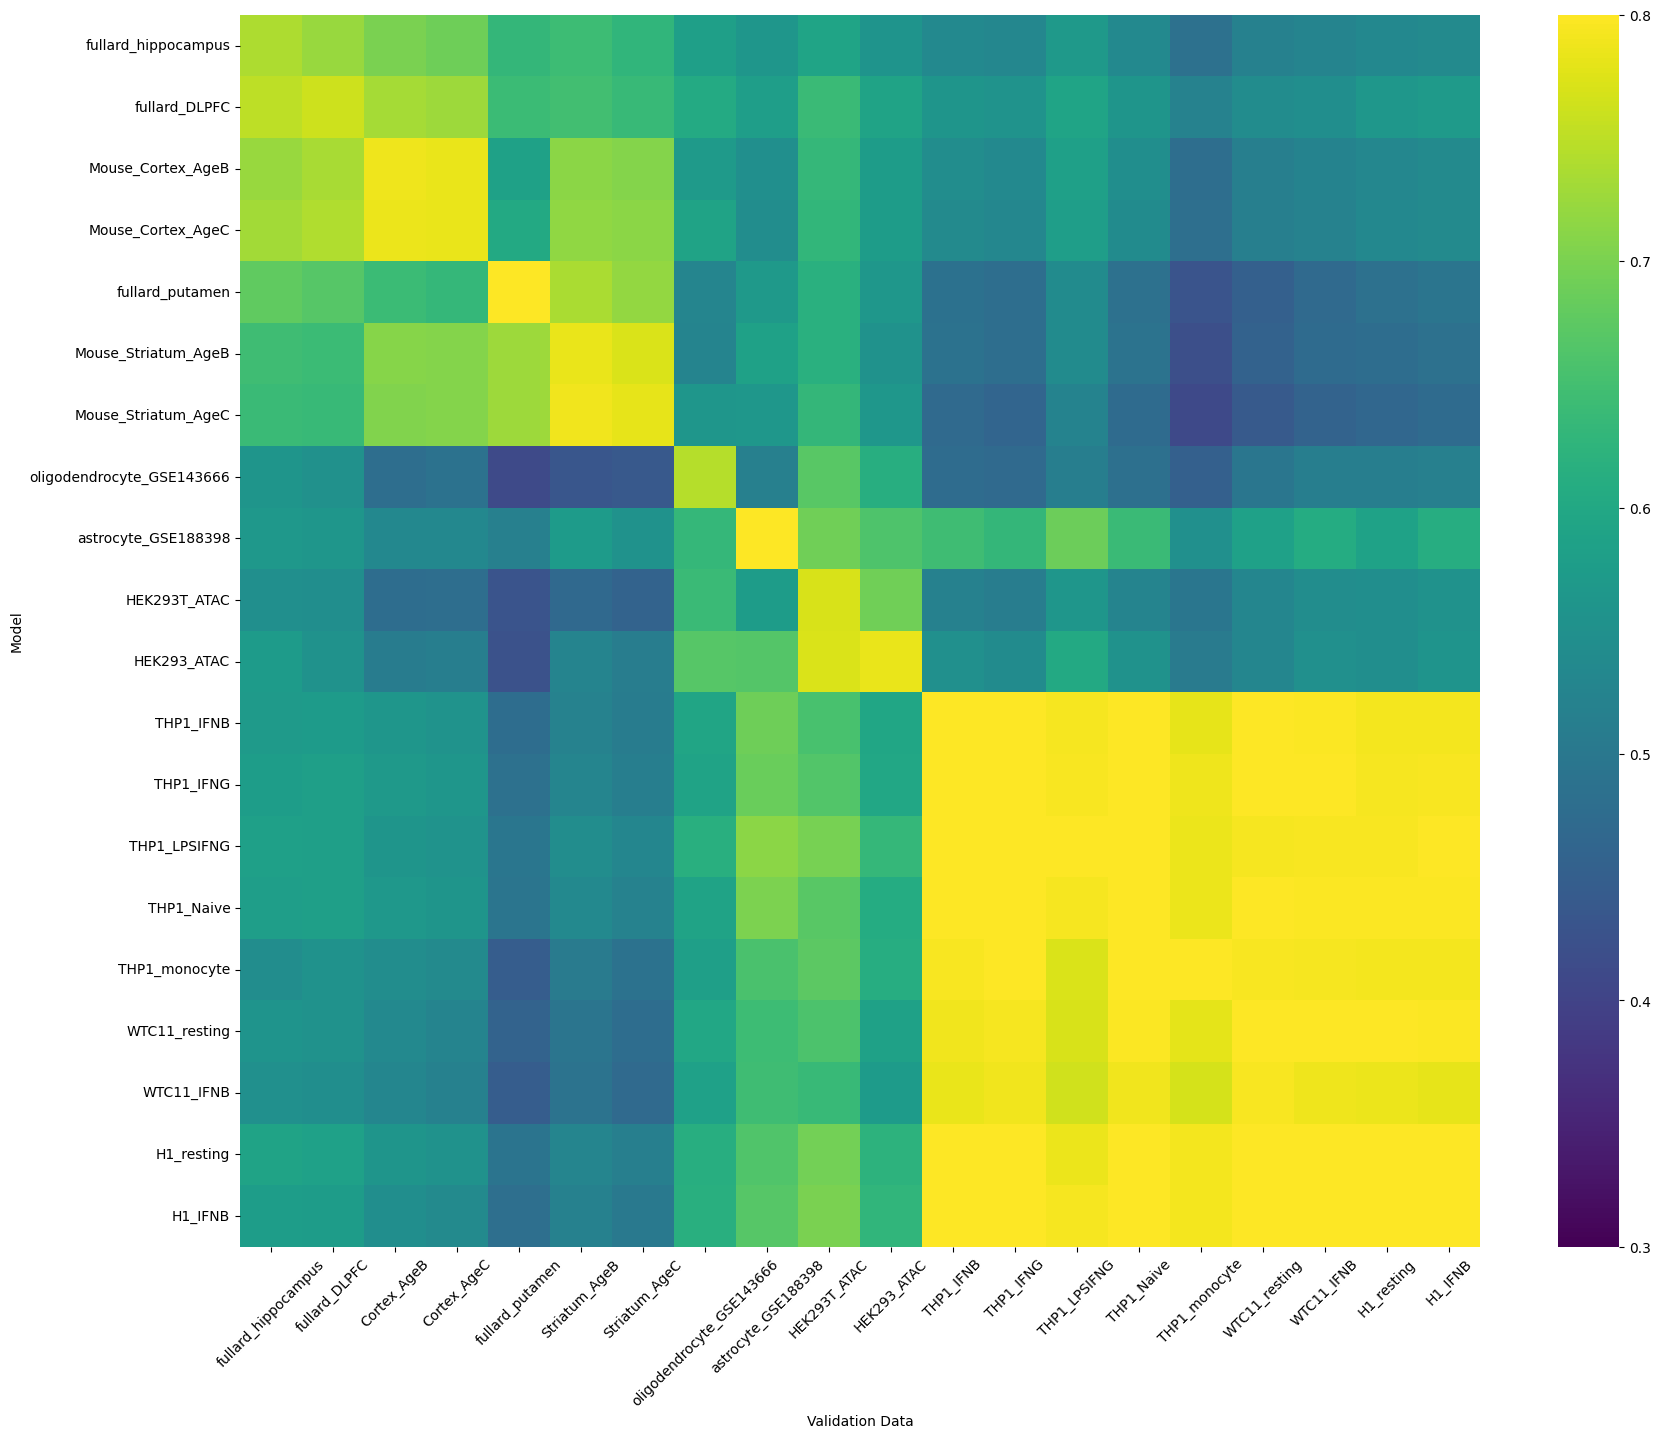

In [ ]:
import os
import numpy as np
import pandas as pd

# 这些必须是 canonicalize() 之后能出现的“规范名”
keywords = [
    # glia (带GSE)
    "astrocyte_GSE188398",
    "oligodendrocyte_GSE143666",

    # fullard (model/test规范名)
    "fullard_DLPFC",
    "fullard_hippocampus",
    "fullard_putamen",   # 你要区分的model

    # H1 / WTC11
    "H1_resting",
    "H1_IFNB",                # 你文件里有 H1_IFNBNEW-model-best_...
    "WTC11_resting",
    "WTC11_IFNB",

    # HEK
    "HEK293T_ATAC",
    "HEK293_ATAC",

    # Cortex/Striatum（test里是 *_ATAC_out_ppr...）
    "Cortex_AgeB",
    "Cortex_AgeC",
    "Striatum_AgeB",
    "Striatum_AgeC",

    # THP1
    "THP1_monocyte",
    "THP1_Naive",
    "THP1_IFNG",
    "THP1_IFNB",
    "THP1_LPSIFNG",

    # 如果你目录里还有 Mouse_* model（你之前列表里有），就把下面四个也打开
    "Mouse_Cortex_AgeB",
    "Mouse_Cortex_AgeC",
    "Mouse_Striatum_AgeB",
    "Mouse_Striatum_AgeC",
]

def canonicalize(name: str) -> str:
    s = name.replace("-", "_")

    # ---------- THP1 ----------
    s = s.replace("THP1_monocytes", "THP1_monocyte")
    s = s.replace("THP1_Naive_4hrs", "THP1_Naive")
    s = s.replace("THP1_IFNB_4hrs", "THP1_IFNB")
    s = s.replace("THP1_IFNG_4hrs", "THP1_IFNG")
    s = s.replace("THP1_LPSIFNG_4hrs", "THP1_LPSIFNG")

    # ---------- WTC11 / H1 ----------
    s = s.replace("WTC11resting", "WTC11_resting")
    s = s.replace("WTC11stimulated", "WTC11_IFNB")

    s = s.replace("H1resting", "H1_resting")
    s = s.replace("H1stimulated", "H1_IFNB")  # 你希望stimulated归到NEW

    # ---------- HEK ----------
    s = s.replace("HEK293_ATAC_high_depth0729", "HEK293_ATAC")
    s = s.replace("HEK293_ATAC_high_depth", "HEK293_ATAC")

    # ---------- Cortex/Striatum test tokens ----------
    # 把 *_ATAC_out_ppr.* 统一成 Cortex_AgeB/Cortex_AgeC/Striatum_AgeB/Striatum_AgeC
    s = s.replace("Cortex_AgeB_ATAC_out_ppr", "Cortex_AgeB")
    s = s.replace("Cortex_AgeC_ATAC_out_ppr", "Cortex_AgeC")
    s = s.replace("Striatum_AgeB_ATAC_out_ppr", "Striatum_AgeB")
    s = s.replace("Striatum_AgeC_ATAC_out_ppr", "Striatum_AgeC")

    # ---------- fullard ----------
    # DLPFC/hippocampus 的 neurons 作为 test 统一折叠
    s = s.replace("fullard_DLPFC_neurons", "fullard_DLPFC")
    s = s.replace("fullard_hippocampus_neurons", "fullard_hippocampus")

    # putamen_neurons 你要保留（model/test都可能出现）
    # optimal_peak 版本也归到 putamen_neurons（不要折叠成 putamen）
    s = s.replace("fullard_putamen_neurons", "fullard_putamen")

    return s

def find_best_keyword(s: str, keywords):
    s2 = canonicalize(s)
    hits = [k for k in keywords if k in s2]
    if not hits:
        return None, s2
    hits.sort(key=len, reverse=True)  # 最长优先，避免 astrocyte 抢 astrocyte_GSE188398
    return hits[0], s2

def build_model_test_matrix(directory, keywords, value_col=0, pairmean=True):
    files = [f for f in os.listdir(directory) if f.endswith(".csv")]
    cols = {}
    report = []

    for f in files:
        model = test = None

        if "-model-best_" in f:
            left, right = f.split("-model-best_", 1)
            model, _ = find_best_keyword(left, keywords)
            test,  _ = find_best_keyword(right, keywords)
        else:
            # fallback: THP1_LPSIFNG_Calvin_<TEST>...
            fc = canonicalize(f)
            if fc.startswith("THP1_LPSIFNG_Calvin_"):
                model = "THP1_LPSIFNG"
                remainder = fc.split("THP1_LPSIFNG_Calvin_", 1)[1]
                test, _ = find_best_keyword(remainder, keywords)

        if model is None or test is None:
            report.append((f, "unparsed", model, test))
            continue

        colname = f"{model}:{test}"
        path = os.path.join(directory, f)

        x = pd.read_csv(path, usecols=[value_col], header=None).iloc[:, 0].to_numpy()
        if pairmean:
            n = (len(x) // 2) * 2
            x = x[:n].reshape(-1, 2).mean(axis=1)

        if colname in cols:
            suffix = 2
            newname = f"{colname}__dup{suffix}"
            while newname in cols:
                suffix += 1
                newname = f"{colname}__dup{suffix}"
            colname = newname

        cols[colname] = x

    out = pd.DataFrame({k: pd.Series(v) for k, v in cols.items()})
    out = out.reindex(sorted(out.columns), axis=1)
    report_df = pd.DataFrame(report, columns=["file", "reason", "model_found", "test_found"])
    return out, report_df

# run
directory = "../prediction/enhancer10kb_test_revision"
result_df, report_df = build_model_test_matrix(directory, keywords)

print("CSV files:", len([f for f in os.listdir(directory) if f.endswith(".csv")]))
print("Output columns:", result_df.shape[1])
print("Unparsed files:", report_df.shape[0])
report_df.head(20)

files = os.listdir('../expand_peaks_500bp_hg38andmm10_revision' )
exclude_files = {
    'THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.narrowPeak.test.withNeg.bed',
    'THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.narrowPeak.test.withNeg.bed',
    'THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.narrowPeak.test.withNeg.bed',
    'THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.narrowPeak.test.withNeg.bed'
}
dataframe = pd.DataFrame()
keyword_bed = []
for file in files:
    if file.endswith('.bed'):
        for key in keywords:
            if key in file and "test.withNeg" in file and file not in exclude_files:
                keyword_bed.append(key)
                file_path = os.path.join('../expand_peaks_500bp_hg38andmm10_revision' , file)

                df = pd.read_csv(file_path, usecols=[6],sep='\t',header=None)
                df.columns = [key]
                dataframe = pd.concat([dataframe, df], axis=1)
dataframe

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Calculating correlation
correlation = []
for c in result_df.columns:
    model = c.split(':')[0]
    validation = c.split(':')[1]
    for d in dataframe.columns:
        if validation == d:
            statistic, p = stats.spearmanr(result_df[c].dropna().reset_index(drop=True), dataframe[d].dropna().reset_index(drop=True))
            correlation.append([model, validation, statistic, p])

df = pd.DataFrame(correlation, columns=['Model', 'Validation Data', 'Value', 'Extra'])
df_pivot = df.pivot(index='Model', columns='Validation Data', values='Value')

# Columns for the heatmap
column1 = ['fullard_hippocampus','fullard_DLPFC','Mouse_Cortex_AgeB', 'Mouse_Cortex_AgeC', 'fullard_putamen',
           'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC', 'oligodendrocyte_GSE143666','astrocyte_GSE188398','HEK293T_ATAC', 'HEK293_ATAC', 'THP1_IFNB', 'THP1_IFNG',
           'THP1_LPSIFNG', 'THP1_Naive', 'THP1_monocyte','WTC11_resting','WTC11_IFNB','H1_resting','H1_IFNB']
# Columns for the heatmap
column2 = ['fullard_hippocampus','fullard_DLPFC','Cortex_AgeB', 'Cortex_AgeC', 'fullard_putamen',
           'Striatum_AgeB', 'Striatum_AgeC', 'oligodendrocyte_GSE143666','astrocyte_GSE188398','HEK293T_ATAC', 'HEK293_ATAC', 'THP1_IFNB', 'THP1_IFNG',
           'THP1_LPSIFNG', 'THP1_Naive', 'THP1_monocyte','WTC11_resting','WTC11_IFNB','H1_resting','H1_IFNB']#'H1_IFNBNEW'''

df_show = df_pivot.loc[column1, column2]
# Creating the heatmap
plt.figure(figsize=(20, 16))  # Adjusting figure size if needed
heatmap = sns.heatmap(df_show, annot=False, cmap='viridis', cbar=True, vmin=0.3, vmax=0.8)
#plt.title("CNN Trained on Specific Cell Types vs Both Positive and Negative Sequences in Validation Data")
plt.xticks(rotation=45)
# Saving the figure with high DPI
plt.savefig('Models_vs_test_revision.pdf', dpi=300, bbox_inches='tight')  # You can adjust the dpi value as needed
plt.show()

In [6]:
df['Validation Data'].unique()


<StringArray>
[              'Cortex_AgeB',               'Cortex_AgeC',
                   'H1_IFNB',                'H1_resting',
              'HEK293T_ATAC',               'HEK293_ATAC',
             'Striatum_AgeB',             'Striatum_AgeC',
                 'THP1_IFNB',                 'THP1_IFNG',
              'THP1_LPSIFNG',                'THP1_Naive',
             'THP1_monocyte',                'WTC11_IFNB',
             'WTC11_resting',       'astrocyte_GSE188398',
             'fullard_DLPFC',       'fullard_hippocampus',
           'fullard_putamen', 'oligodendrocyte_GSE143666']
Length: 20, dtype: str

# GC Content correlation to prediction

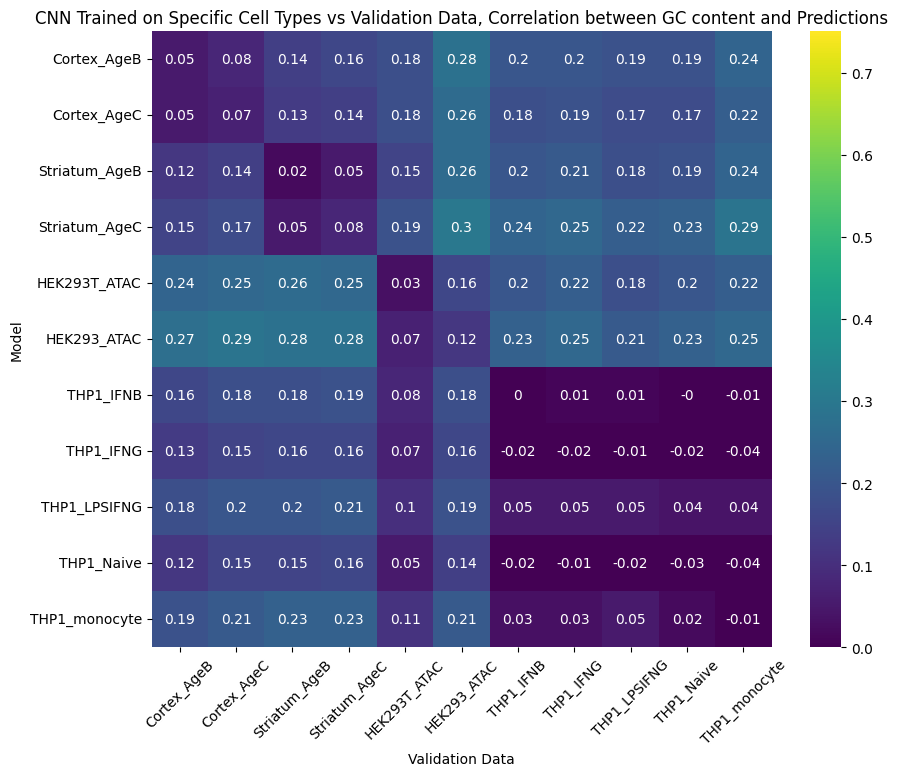

In [ ]:
files = os.listdir('../expand_peaks_500bp_fasta_hg38andmm10' )

dataframe = pd.DataFrame()

for file in files:
    for neg_file in files:
        if file.endswith('.fasta'):
            for key in keywords:
                if (key in file and "validation" in file and "background" not in file) and (key in neg_file and "validation" in neg_file and "background" in neg_file):
                    file_path = os.path.join('../expand_peaks_500bp_fasta_hg38andmm10' , file)
                    df = fasta_to_dataframe(file_path).reset_index()
                    file_path_neg = os.path.join('../expand_peaks_500bp_fasta_hg38andmm10' , neg_file)
                    df_neg = fasta_to_dataframe(file_path_neg).reset_index()

                    df_both = pd.concat([df, df_neg]).reset_index(drop=True)
                    df_both[key] = df_both['Sequence'].apply(calculate_gc_content)

                    dataframe = pd.concat([dataframe, df_both[[key]]], axis=1)


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Calculating correlation
correlation = []
for c in result_df.columns:
    model = c.split(':')[0]
    validation = c.split(':')[1]
    for d in dataframe.columns:
        if validation == d:
            statistic, p = stats.spearmanr(result_df[c].dropna().reset_index(drop=True), dataframe[d].dropna().reset_index(drop=True))
            correlation.append([model, validation, round(statistic,2), p])

df = pd.DataFrame(correlation, columns=['Model', 'Validation Data', 'Value', 'Extra'])
df_pivot = df.pivot(index='Model', columns='Validation Data', values='Value')

# Columns for the heatmap
columns = ['Cortex_AgeB', 'Cortex_AgeC', 
           'Striatum_AgeB', 'Striatum_AgeC', 'HEK293T_ATAC', 'HEK293_ATAC', 'THP1_IFNB', 'THP1_IFNG',
           'THP1_LPSIFNG', 'THP1_Naive', 'THP1_monocyte']

# Creating the heatmap
plt.figure(figsize=(10, 8))  # Adjusting figure size if needed
heatmap = sns.heatmap(df_pivot.loc[columns, columns], annot=True, cmap='viridis', cbar=True,vmin=0,vmax=0.75)
plt.title("CNN Trained on Specific Cell Types vs Validation Data, Correlation between GC content and Predictions")
plt.xticks(rotation=45)
# Saving the figure with high DPI
plt.savefig('Models_vs_Validations_GC_Content_Correlation.pdf', dpi=300, bbox_inches='tight')  # You can adjust the dpi value as needed
plt.show()
